In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata

In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = 'Arial'
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80,facecolor='white')
results_file = 'write/HCC_snRNA.h5ad'
sc.settings.set_figure_params(dpi = 100,dpi_save= 300,figsize = (5,5))

C:\Soft\Anaconda\envs\scanpy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.3 anndata==0.10.9 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.3 igraph==0.11.6 pynndescent==0.5.13


In [3]:
adata_raw = sc.read_h5ad("adata_raw.h5ad")

In [4]:
metadata = pd.read_csv('adata.obs.csv')

In [5]:
adata_raw.obs['Celltype'] = metadata['Celltype'].values

In [6]:
adata_E = adata_raw[adata_raw.obs['Celltype'].isin(['Epithelial','Club cell',"AT2","Basal cell"])]

In [7]:
adata_E

View of AnnData object with n_obs × n_vars = 4182 × 23769
    obs: 'Group', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Celltype'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [8]:
adata_E.write_h5ad("adata_E_raw.h5ad")

C:\Soft\Anaconda\envs\scanpy\lib\site-packages\anndata\_core\anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [9]:
pd.DataFrame(data=adata_E.X.todense().T, index=adata_E.var_names,columns=adata_E.obs_names).to_csv('raw_E_matrix.csv',sep="\t",float_format='%.0f') 

In [10]:
adata_E.raw = adata_E

In [11]:
sc.pp.normalize_total(adata_E,target_sum = 1e4)
sc.pp.log1p(adata_E)

normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


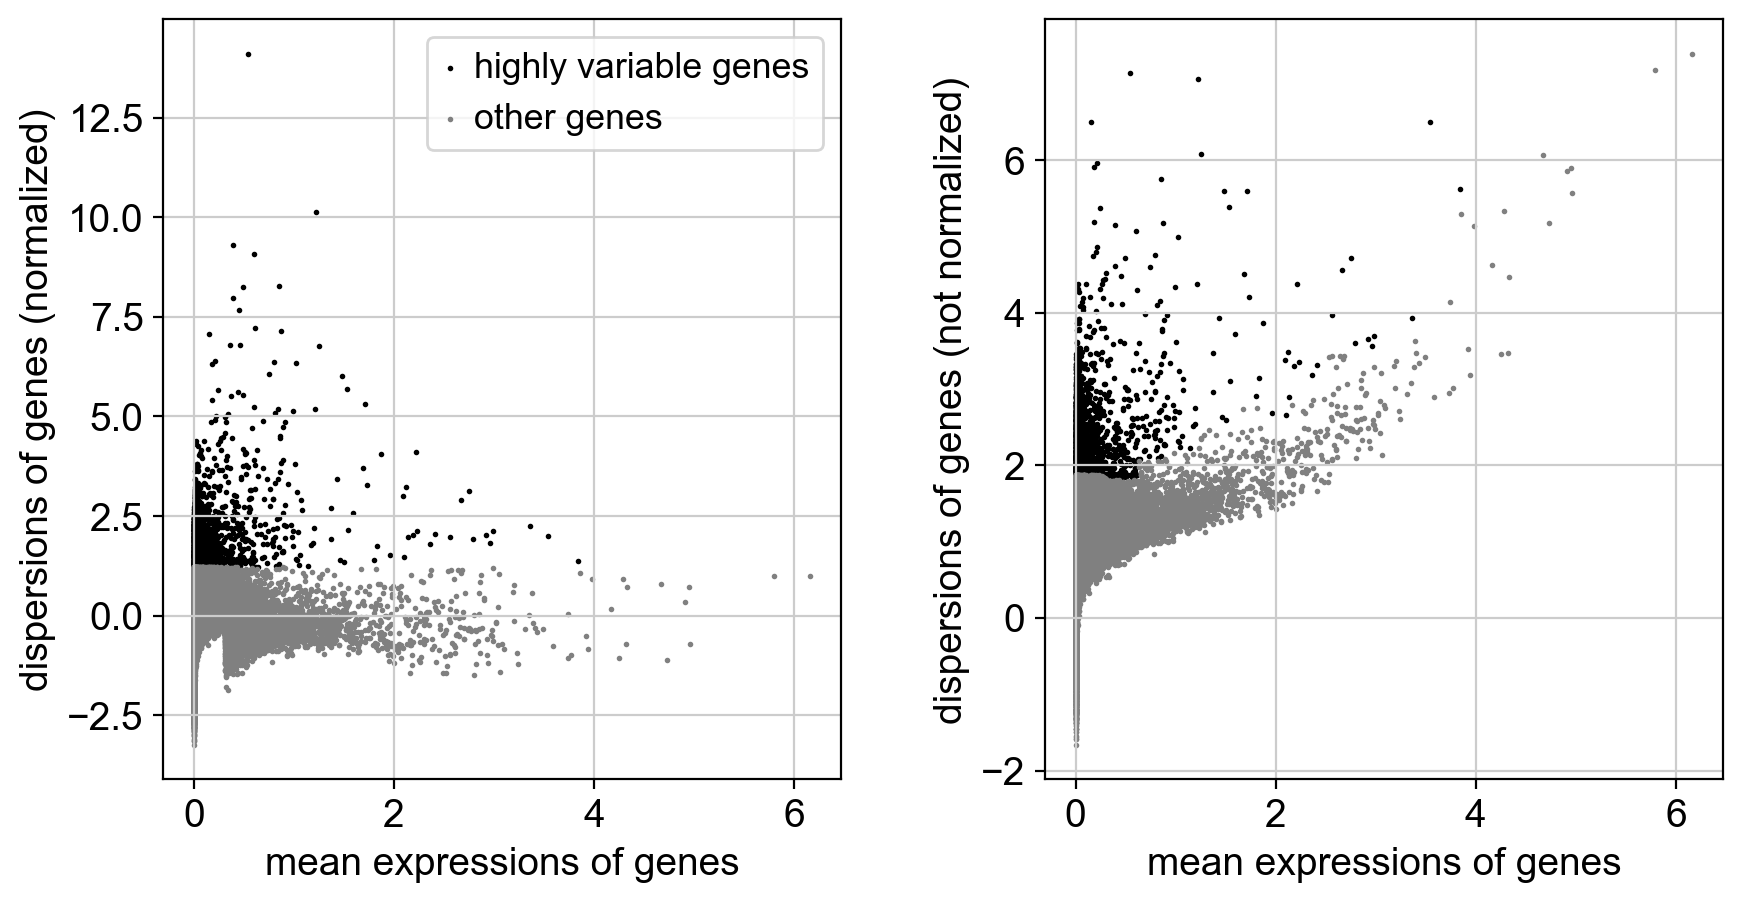

In [12]:
sc.pp.highly_variable_genes(adata_E,min_mean = 0.0125,max_mean = 3,min_disp = 0.5,n_top_genes = 2000)
sc.pl.highly_variable_genes(adata_E,save = '.E_scRNA.pdf')

In [13]:
adata_E = adata_E[:,adata_E.var.highly_variable]
sc.pp.regress_out(adata_E,['total_counts'])
sc.pp.scale(adata_E,max_value = 10)

regressing out ['total_counts']
    sparse input is densified and may lead to high memory use


C:\Soft\Anaconda\envs\scanpy\lib\site-packages\scanpy\preprocessing\_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:07)


computing PCA
    with n_comps=50
    finished (0:00:01)


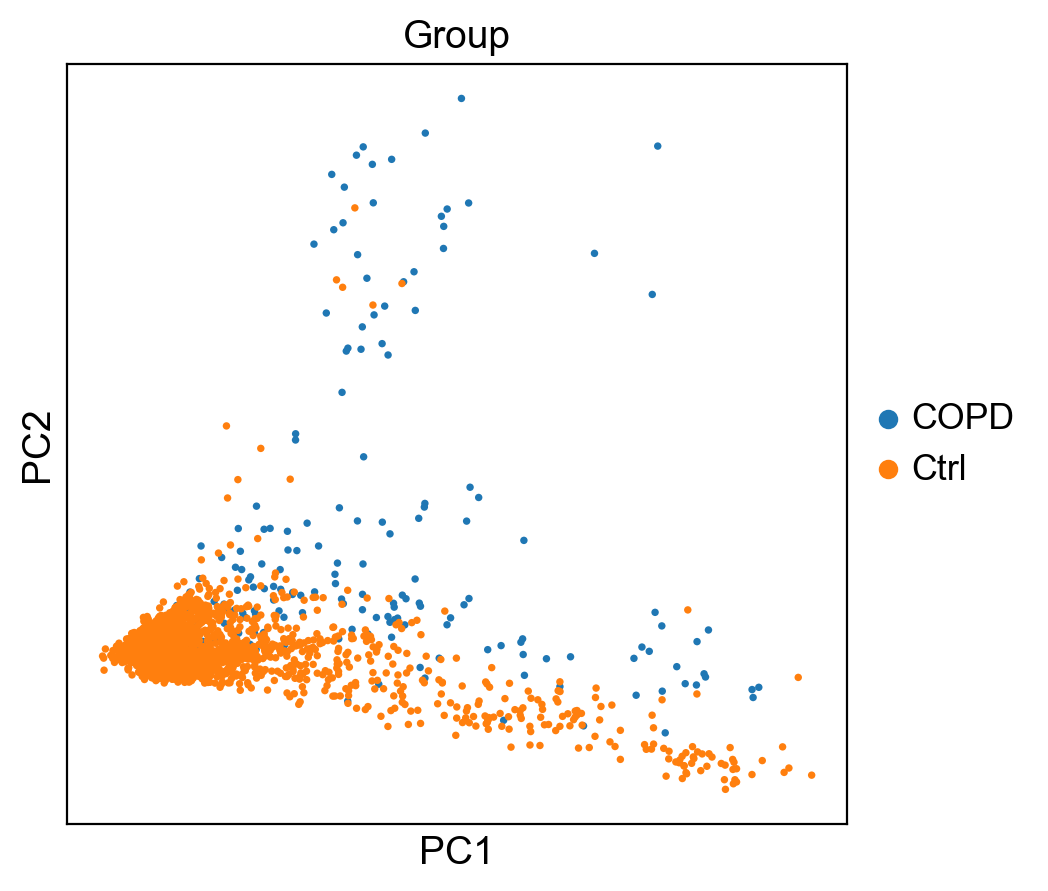

In [14]:
sc.tl.pca(adata_E,svd_solver = 'arpack')
sc.pl.pca(adata_E,color = 'Group')

In [15]:
import harmonypy as hm
meta_data = adata_E.obs
data_mat = adata_E.obsm["X_pca"]
ho = hm.run_harmony(data_mat, meta_data, "batch")
adata_E.obsm["X_pca"] = ho.Z_corr.T

2025-05-26 14:38:00,975 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-05-26 14:38:02,478 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-05-26 14:38:02,507 - harmonypy - INFO - Iteration 1 of 10
2025-05-26 14:38:03,447 - harmonypy - INFO - Iteration 2 of 10
2025-05-26 14:38:04,330 - harmonypy - INFO - Iteration 3 of 10
2025-05-26 14:38:05,224 - harmonypy - INFO - Iteration 4 of 10
2025-05-26 14:38:06,243 - harmonypy - INFO - Iteration 5 of 10
2025-05-26 14:38:06,750 - harmonypy - INFO - Iteration 6 of 10
2025-05-26 14:38:07,191 - harmonypy - INFO - Iteration 7 of 10
2025-05-26 14:38:07,644 - harmonypy - INFO - Converged after 7 iterations


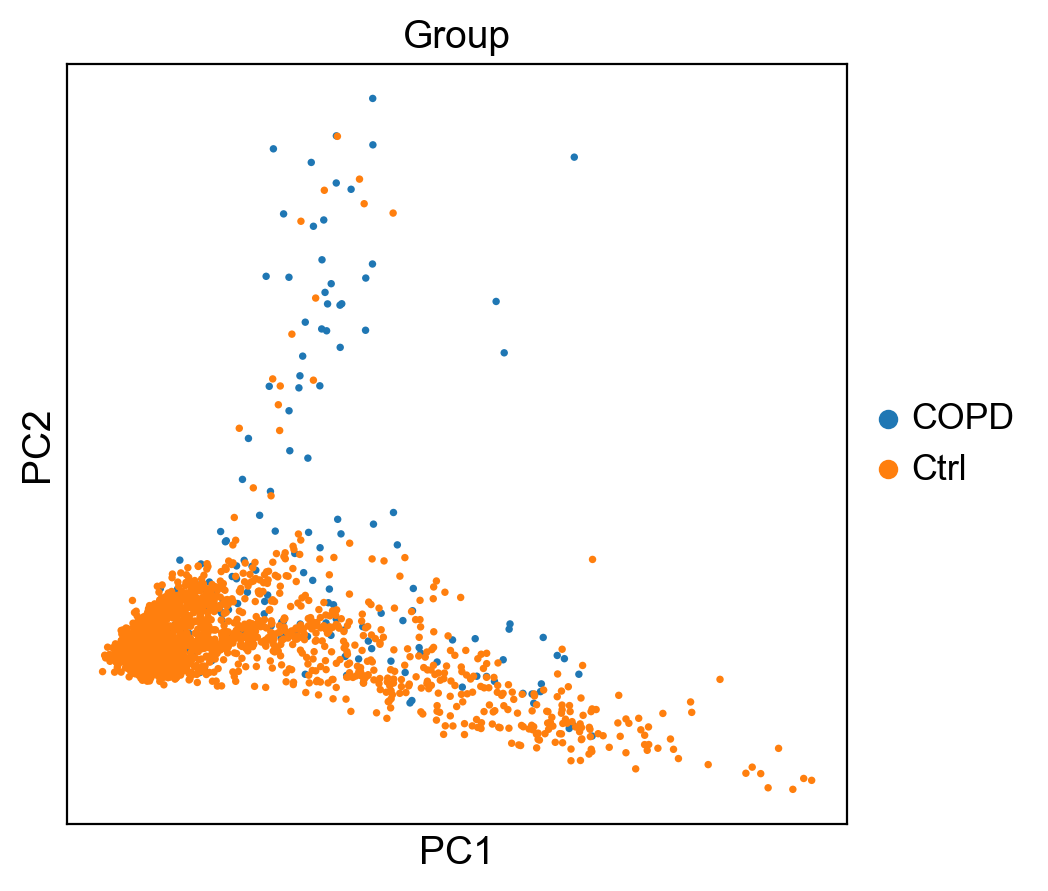

In [16]:
sc.pl.pca(adata_E,color = 'Group')

In [17]:
sc.pp.neighbors(adata_E,n_neighbors = 10,n_pcs = 40)
sc.tl.umap(adata_E)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


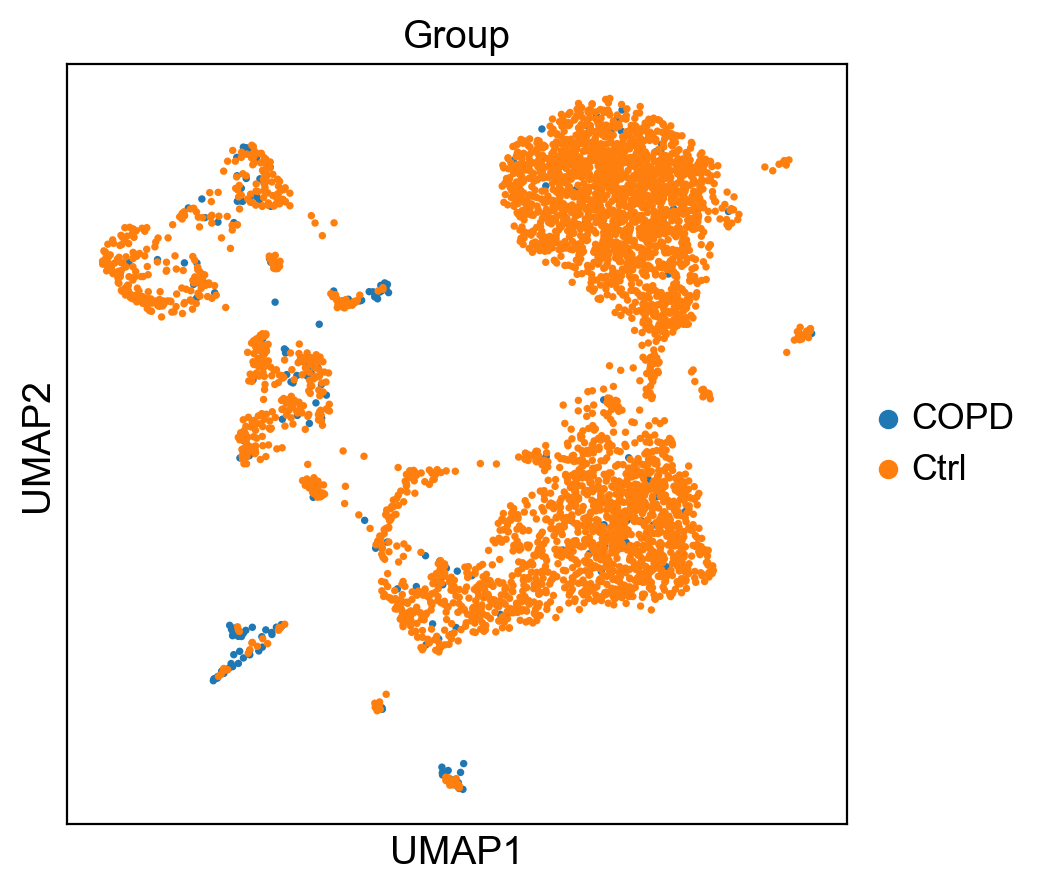

In [18]:
sc.pl.umap(adata_E,color = ['Group'],save = '.E_cluster.pdf')

running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


C:\Users\chenzhen\AppData\Local\Temp\ipykernel_2788\3623634690.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_E,resolution = 0.3)


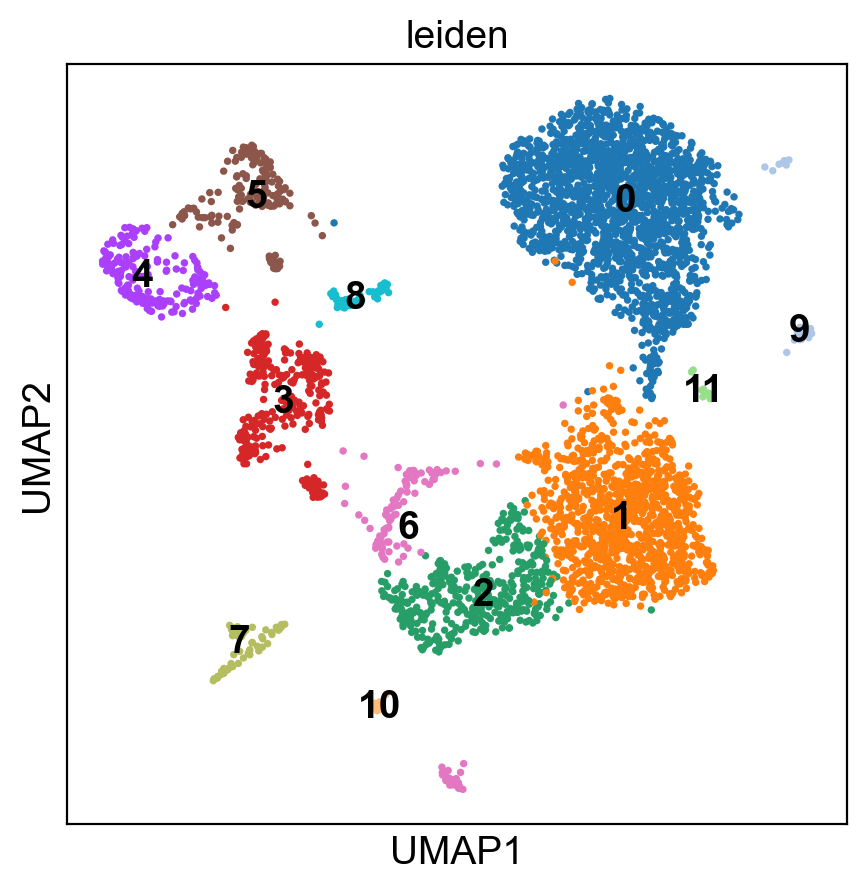

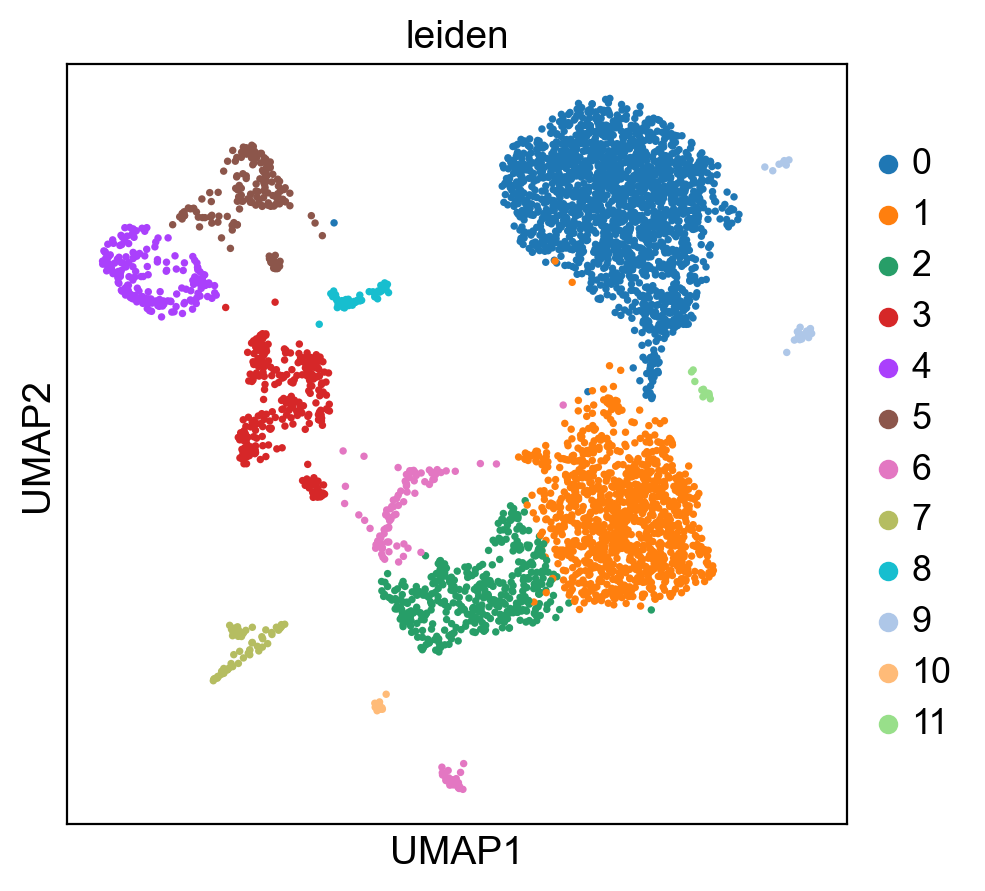

In [19]:
sc.tl.leiden(adata_E,resolution = 0.3)
sc.pl.umap(adata_E,color = ['leiden'],legend_loc='on data',save = '.E_cluster.umap.pdf')
sc.pl.umap(adata_E,color = ['leiden'])

In [20]:
sc.tl.rank_genes_groups(adata_E,'leiden',method = 'wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:10)


In [21]:
#dict_keys(['logfoldchanges', 'names', 'params', 'pvals', 'pvals_adj', 'scores'])
result = adata_E.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(    {group + '_' + key[:1]: result[key][group]    for group in groups for key in ['names', 'pvals']}).head(5)
res = pd.DataFrame(    {group + '_' + key: result[key][group]    for group in groups for key in ['names', 'pvals','logfoldchanges','pvals_adj','scores']})
res.to_csv("E_dif.csv") #基因差异情况输出到本地保存

In [22]:
adata_E.write_h5ad("adata_E_result.h5ad")

In [23]:
adata_E.obs['cell'] = adata_E.obs_names
adata_E.obs.to_csv('adata_E.obs.xls', index=0, sep='\t')

In [1]:
import os,sys
import loompy as lp
import numpy as np
import pandas as pd
os.getcwd()
os.listdir(os.getcwd())

['.ipynb_checkpoints',
 '.Rhistory',
 '204e5e7dd0c28b526dacf19f14f22dc.png',
 'adata.obs.csv',
 'adata.obs.xls',
 'adata_E.obs.xls',
 'adata_E_raw.h5ad',
 'adata_E_result.h5ad',
 'adata_L.obs.xls',
 'adata_L_raw.h5ad',
 'adata_L_result.h5ad',
 'adata_M.obs.xls',
 'adata_M_raw.h5ad',
 'adata_M_result.h5ad',
 'adata_N.obs.xls',
 'adata_N_raw.h5ad',
 'adata_N_result.h5ad',
 'adata_raw.h5ad',
 'adata_result.h5ad',
 'BAL_scRNA.ipynb',
 'BAL_SourceCode.R',
 'cache',
 'Cellannotion.xlsx',
 'dif.csv',
 'E_counts.csv',
 'E_scRNA.ipynb',
 'figures',
 'L_dif.csv',
 'L_scRNA.ipynb',
 'Matrix',
 'Mdif.csv',
 'M_dif.csv',
 'M_scRNA.ipynb',
 'N_dif.csv',
 'N_scRNA.ipynb',
 'raw_E_matrix.csv',
 'raw_L_matrix.csv',
 'raw_matrix.csv',
 'raw_matrix.csv.gz',
 'raw_M_matrix.csv',
 'raw_M_matrix.csv.gz',
 'raw_N_matrix.csv',
 '各个类型平行分析.pdf']

In [2]:
counts=pd.read_csv("E_counts.csv",index_col = 0, header = 0)
features = counts.index.tolist()
barcodes = counts.columns.tolist()
#loom行属性：用于存储与基因相关的元数据。这些属性可以包括基因名称、基因长度、基因所属的染色体等信息。
#loom列属性：存储与细胞相关的元数据。例如细胞类型等信息。

In [3]:
row_attrs = {'Gene':np.array(features)}
col_attrs = {'CellID':np.array(barcodes)}
lp.create("E_counts.loom", counts.values,row_attrs,col_attrs)

In [4]:
adata_E = sc.read_h5ad("adata_E_result.h5ad")

In [5]:
metadata = pd.read_csv('adata_E.obs.csv')

In [6]:
metadata

,cell,Group,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,Celltype,leiden,Celltype2
0,AAACGGGTCCGCAAGC-1-0,COPD,0,413,413,541,1,0.184843,AT2,5,Basal cell
1,AGAGCGAAGTCCTCCT-1-0,COPD,0,3233,3233,8885,238,2.678672,Epithelial,6,Basal cell
2,AGAGTGGTCATGTCCC-1-0,COPD,0,4945,4944,13077,161,1.231169,Epithelial,0,Ciliated cell
3,AGCTCCTGTTCCACAA-1-0,COPD,0,397,397,620,0,0.000000,Club cell,1,Club cell
4,ATAGACCGTCCAGTTA-1-0,COPD,0,5503,5500,18533,588,3.172719,Epithelial,0,Ciliated cell
...,...,...,...,...,...,...,...,...,...,...,...
4177,TTGTAGGTCAATAAGG-1-7,Ctrl,7,5670,5669,21378,949,4.439143,Epithelial,0,Ciliated cell
4178,TTTATGCCACATGACT-1-7,Ctrl,7,1689,1689,2606,192,7.367613,Epithelial,0,Ciliated cell
4179,TTTCCTCCAAGTACCT-1-7,Ctrl,7,4373,4370,11740,190,1.618399,Epithelial,3,Mesenchymal cell
4180,TTTCCTCTCTCGATGA-1-7,Ctrl,7,286,286,579,5,0.863558,Epithelial,3,Mesenchymal cell


In [7]:
adata_E.obs['Celltype'] = metadata['Celltype2'].values

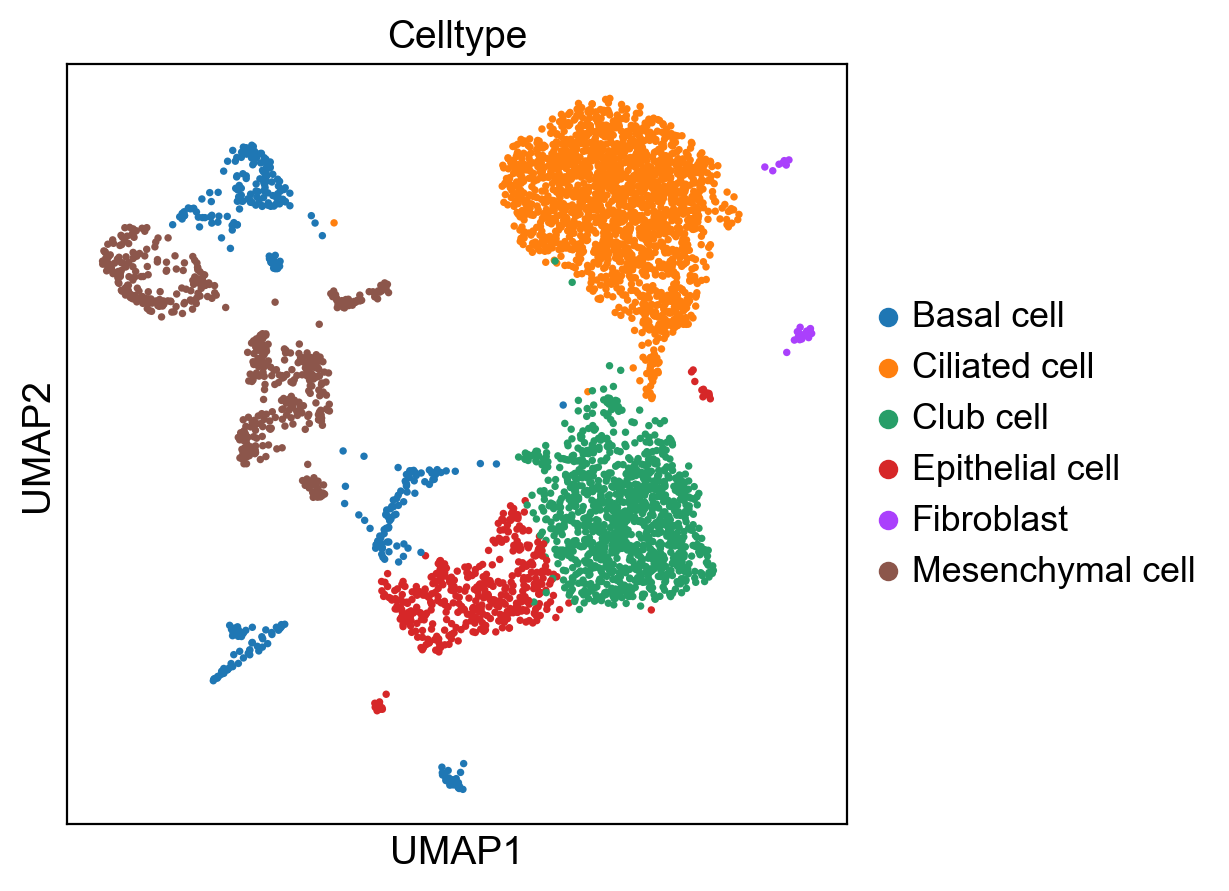

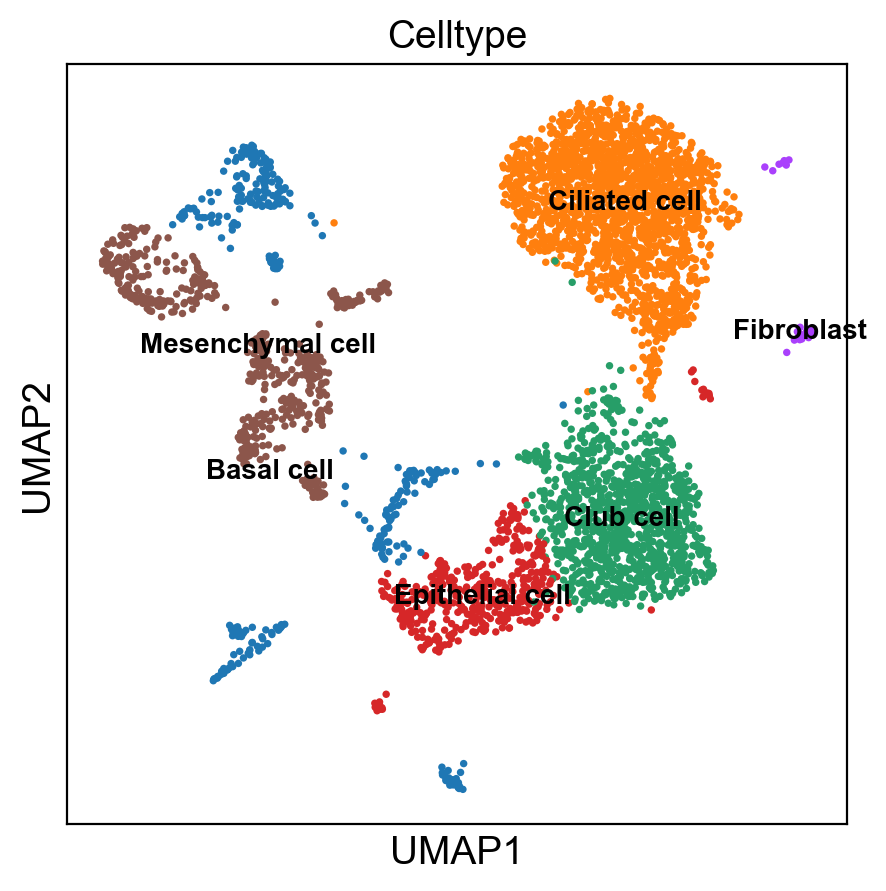

In [8]:
sc.pl.umap(adata_E, color=['Celltype'],save = '.ECelltype.pdf')
sc.pl.umap(adata_E, color=['Celltype'],legend_loc='on data',legend_fontsize=10,save = '.ECelltype2.pdf')

In [9]:
adata_E.write_h5ad("adata_E_result.h5ad")

In [3]:
adata_E = sc.read_h5ad("adata_E_result.h5ad")

In [9]:
scissor = pd.read_csv('Escissor_result.csv')

In [10]:
adata_E.obs['scissor'] = scissor['scissor'].values

In [11]:
custom_colors = {
    'Scissor_none': 'grey',
    'Scissor_pos': 'red',
    'Scissor_neg': 'blue'
}

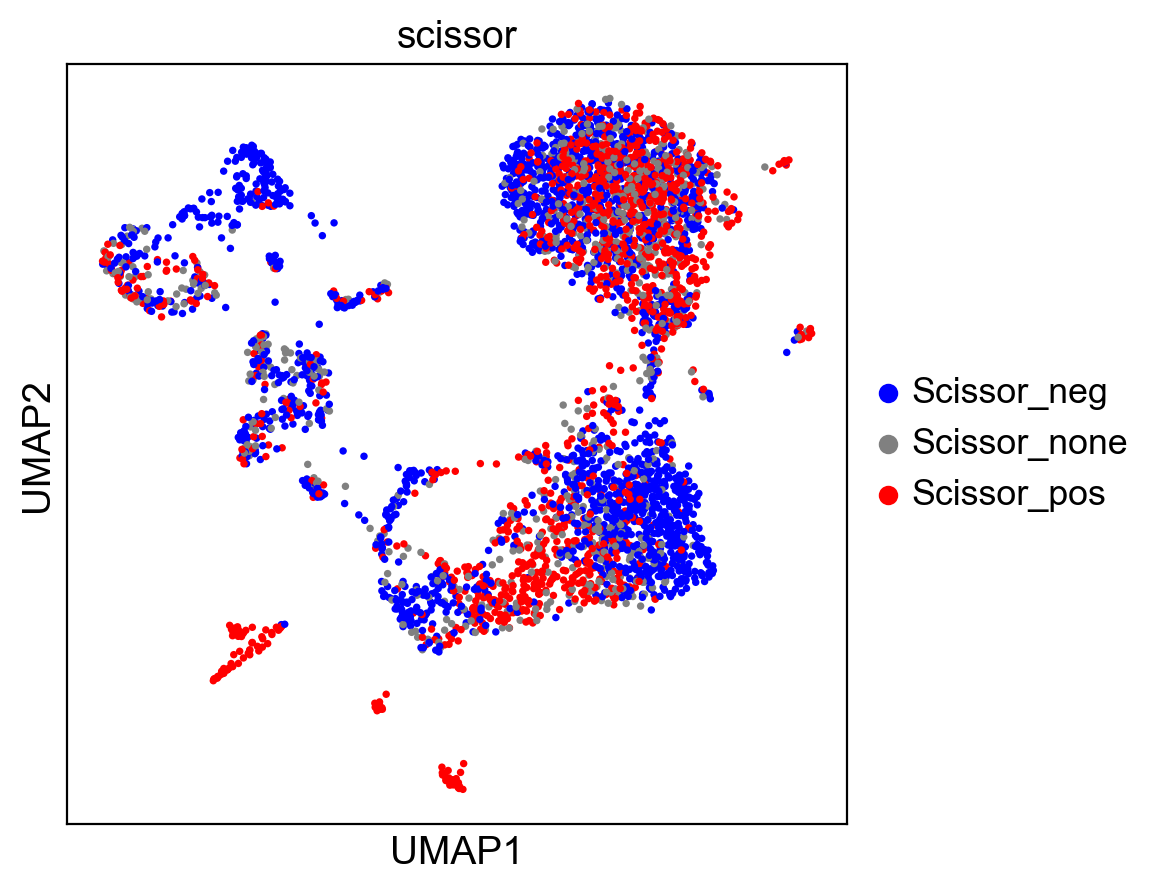

In [12]:
sc.pl.umap(adata_E, color=['scissor'],palette=custom_colors,save = '.EScissor.pdf')

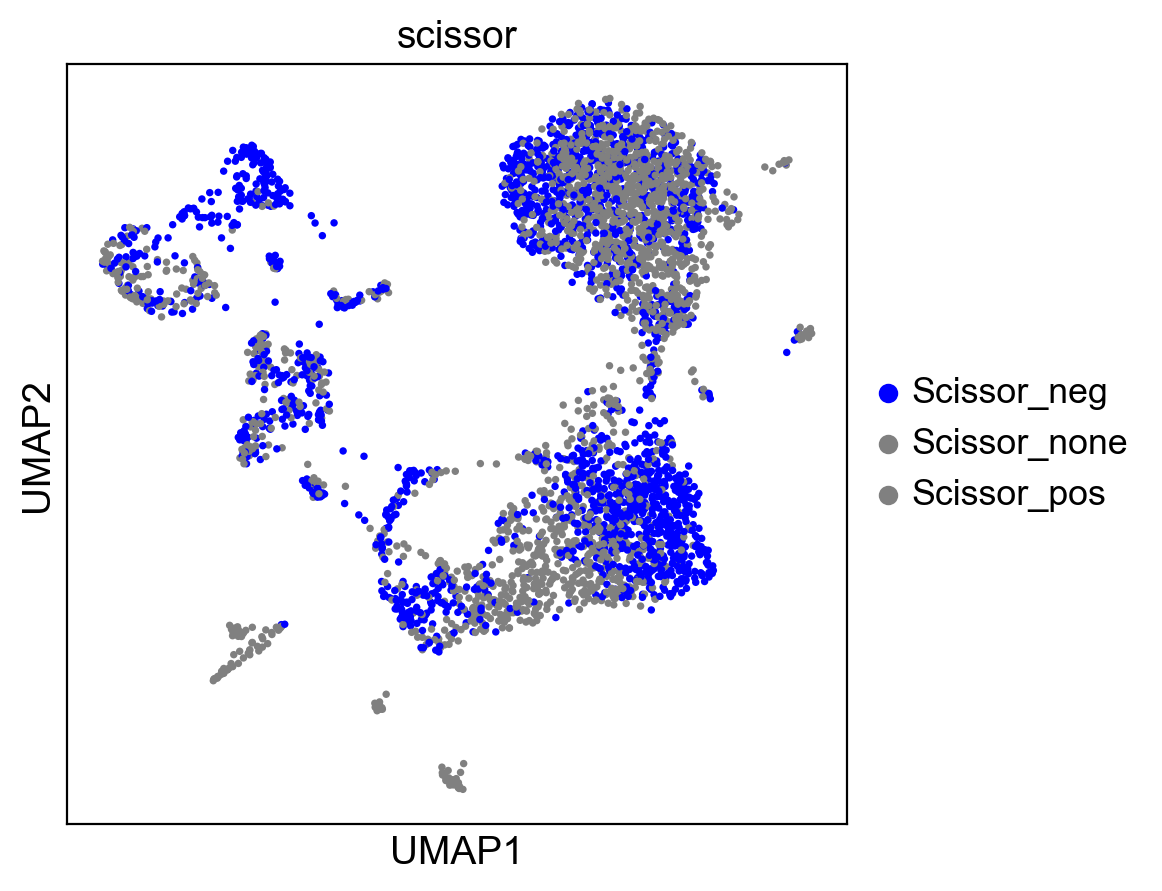

In [14]:
custom_colors = {
    'Scissor_none': 'grey',
    'Scissor_pos': 'grey',
    'Scissor_neg': 'blue'
}
sc.pl.umap(adata_E, color=['scissor'],palette=custom_colors,save = '.EScissor_neg.pdf')

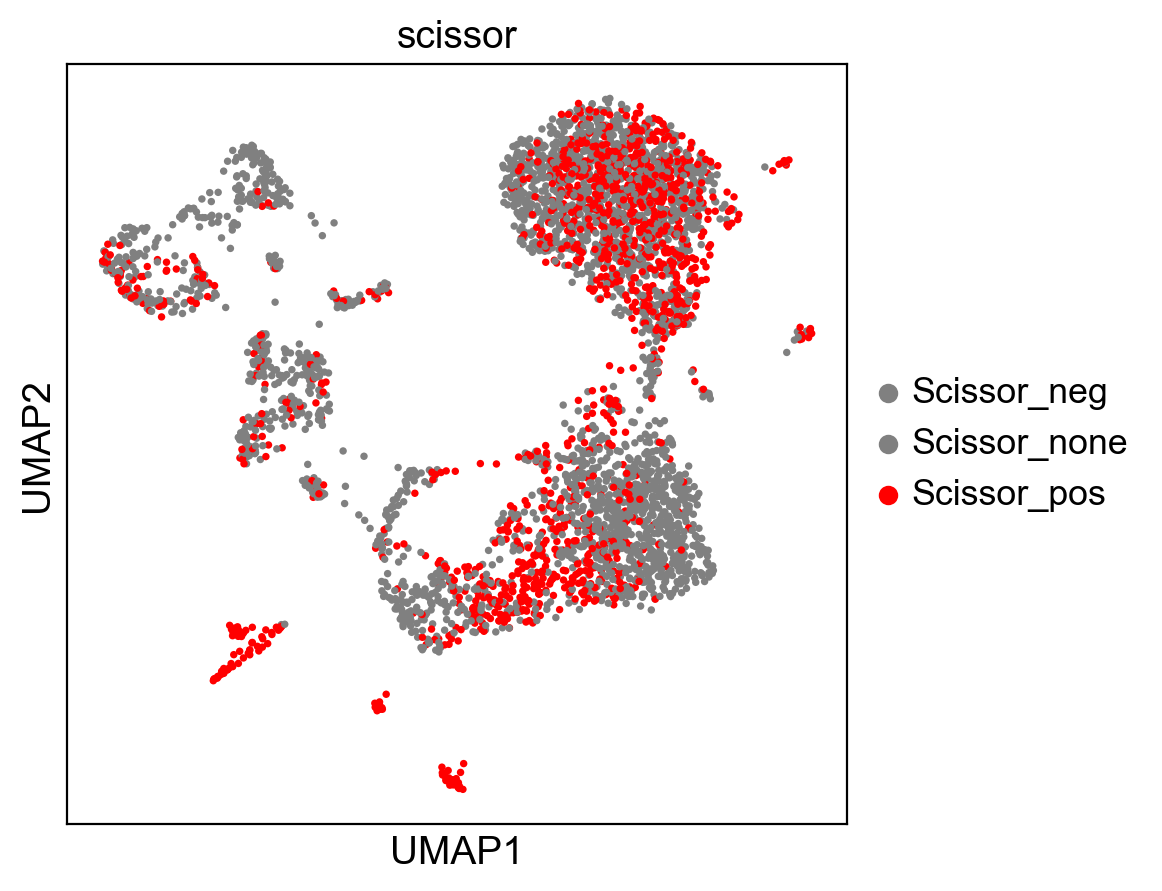

In [15]:
custom_colors = {
    'Scissor_none': 'grey',
    'Scissor_pos': 'red',
    'Scissor_neg': 'grey'
}
sc.pl.umap(adata_E, color=['scissor'],palette=custom_colors,save = '.EScissor_pos.pdf')